# **Import necessary libraries**

In [1]:
!pip install catboost

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# **Load the dataset**

In [3]:
Customer_Churn = pd.read_csv('/content/Churn_Modelling.csv')

# **Check the data info **

In [4]:
data_info = Customer_Churn.info()
print("Data Information:\n", data_info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
Data Information:
 None


# **Check for missing data**

In [5]:
missing_data = Customer_Churn.isnull().sum()
print("\nMissing Data:\n", missing_data)


Missing Data:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


# **Check for duplicate data**

In [6]:
duplicate_data = Customer_Churn.duplicated().sum()
print("\nDuplicate Rows:\n", duplicate_data)


Duplicate Rows:
 0


# **Summary Statistics**

In [7]:
#  Summary statistics for numerical features
summary_statistics = Customer_Churn.describe()

# Displaying the summary statistics for numerical features
print("Summary Statistics for Numerical Features:")
print(summary_statistics)

Summary Statistics for Numerical Features:
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584  

# **Visualizing Data Distribution (Histograms)**

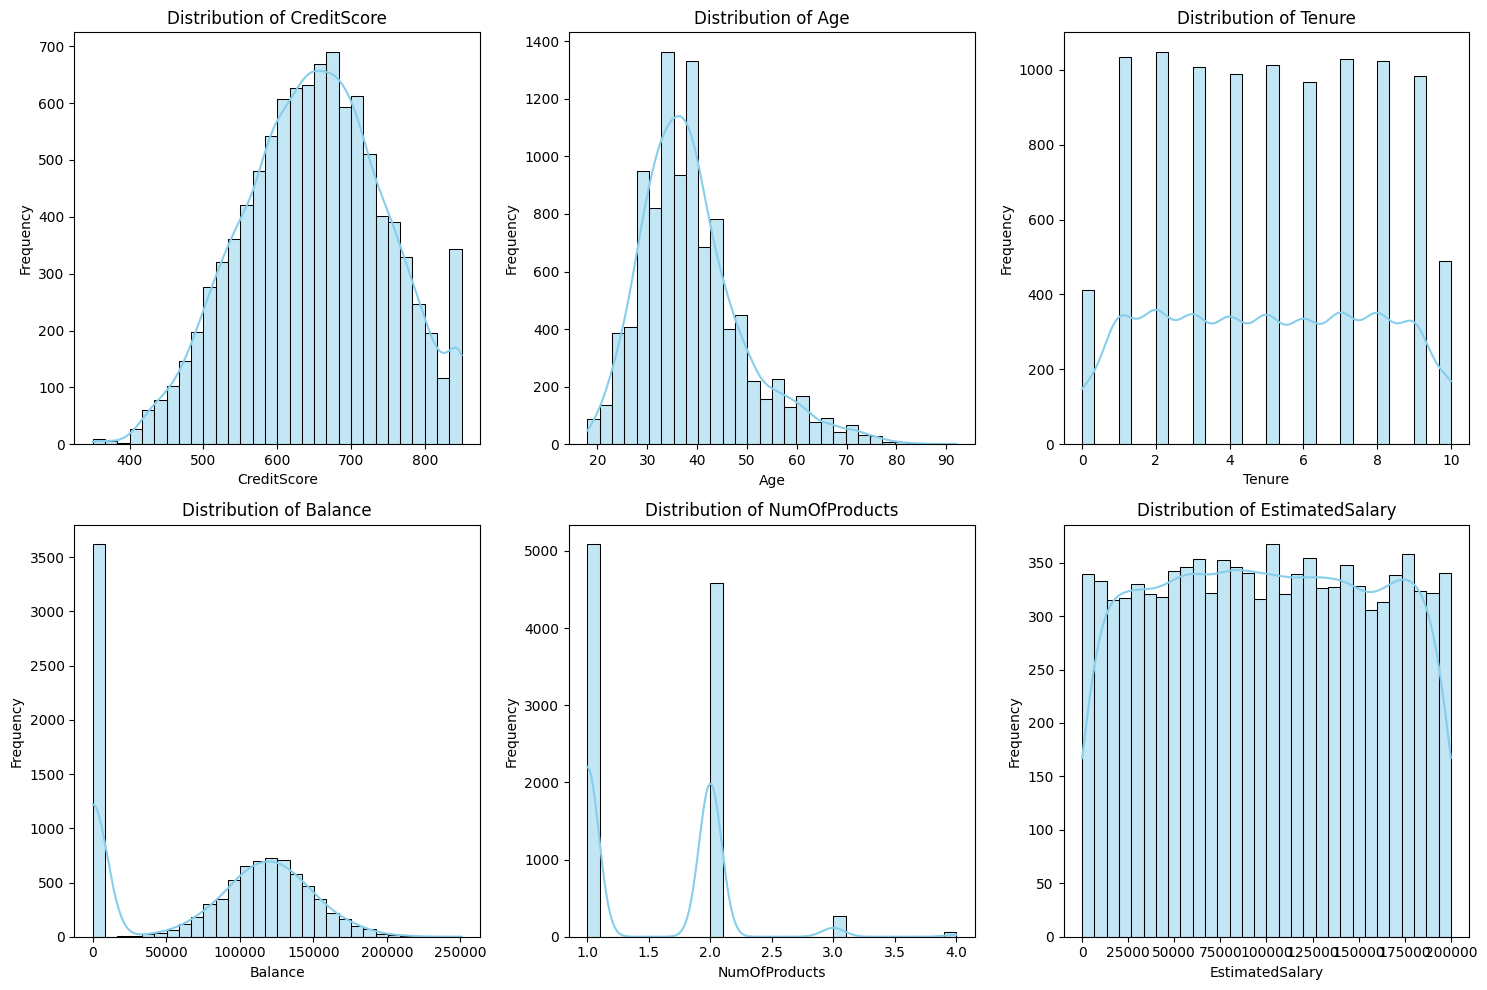

In [8]:
# List of numerical columns to visualize
numerical_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

plt.figure(figsize=(15, 10))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)  # 2 rows and 3 columns
    sns.histplot(Customer_Churn[column], kde=True, color="skyblue", bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# **Visualizing Categorical Data**

/tmp/ipykernel_12846/848746964.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Customer_Churn, x='Geography', palette='viridis')
/tmp/ipykernel_12846/848746964.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Customer_Churn, x='Gender', palette='magma')


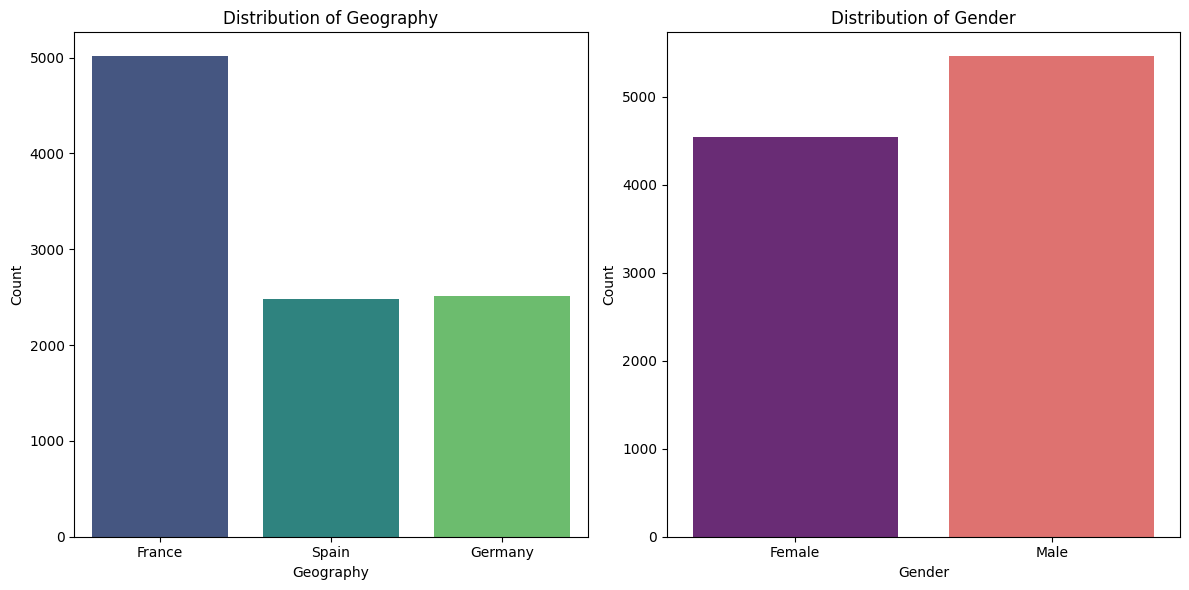

In [9]:
#  Visualize categorical features using bar plots
plt.figure(figsize=(12, 6))

# Plotting 'Geography' distribution
plt.subplot(1, 2, 1)
sns.countplot(data=Customer_Churn, x='Geography', palette='viridis')
plt.title('Distribution of Geography')
plt.xlabel('Geography')
plt.ylabel('Count')

# Plotting 'Gender' distribution
plt.subplot(1, 2, 2)
sns.countplot(data=Customer_Churn, x='Gender', palette='magma')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# **Correlation Heatmap**

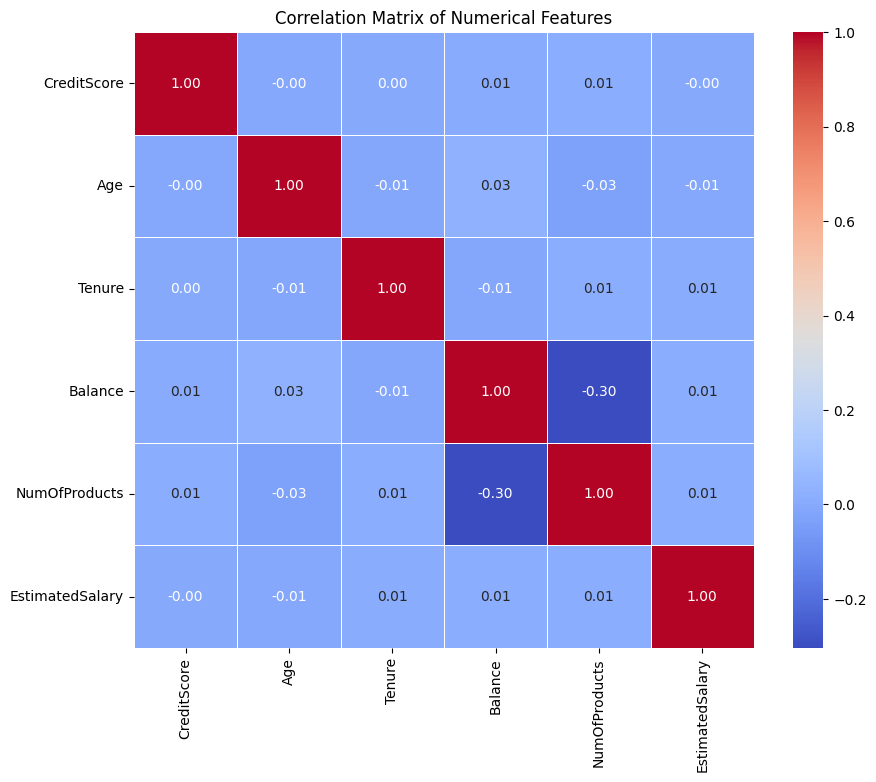

In [10]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
correlation_matrix = Customer_Churn[numerical_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# One-Hot Encoding for categorical features

In [11]:
column_transformer = ColumnTransformer(
    transformers=[
        ('geo_gender', OneHotEncoder(), ['Geography', 'Gender']),  # One-hot encoding
        ('scaler', StandardScaler(), ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary'])  # Scaling numerical features
    ],
    remainder='passthrough'  # Leave other columns (such as 'RowNumber', 'CustomerId', 'Surname', 'Exited') as they are
)

# **Split the data into features (X) and target (y)**

In [12]:
X = Customer_Churn.drop(columns=['Exited', 'RowNumber', 'CustomerId', 'Surname'])  # Drop non-feature columns
y = Customer_Churn['Exited']  # 'Exited' is the target variable

# **Split the dataset into training and test sets (80% train, 20% test)**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Create a pipeline to apply transformations and train a model**

In [14]:
pipeline = Pipeline(steps=[
    ('preprocessor', column_transformer)  # Apply the column transformer to the features
])

In [15]:
# Fit and transform the training data
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

In [16]:
print("Processed training data shape:", X_train_processed.shape)
print("Processed test data shape:", X_test_processed.shape)

Processed training data shape: (8000, 13)
Processed test data shape: (2000, 13)


# **Train and Evaluate Models**

# **Logistic Regression**

In [17]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [18]:
log_reg_pred = log_reg.predict(X_test_processed)

# **XGBoost**

In [19]:
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train_processed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [20]:
xgb_pred = xgb_model.predict(X_test_processed)

# **LightGBM**

In [21]:
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train_processed, y_train)

[LightGBM] [Info] Number of positive: 1644, number of negative: 6356
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003900 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205500 -> initscore=-1.352267
[LightGBM] [Info] Start training from score -1.352267


LGBMClassifier(random_state=42)

In [22]:
lgb_pred = lgb_model.predict(X_test_processed)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# **CatBoost**

In [23]:
catboost_model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, verbose=0, random_state=42)
catboost_model.fit(X_train_processed, y_train)

CatBoostClassifier(depth=6, iterations=1000, learning_rate=0.1, random_state=42, verbose=0)

In [24]:
catboost_pred = catboost_model.predict(X_test_processed)

# *Evaluate the models*

In [25]:
models = {
    "Logistic Regression": log_reg_pred,
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred,
    "CatBoost": catboost_pred
}

In [26]:
# Function to display performance metrics
def evaluate_model(predictions, model_name):
    accuracy = accuracy_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, predictions)
    class_report = classification_report(y_test, predictions)
    print(f"Evaluation for {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Classification Report:\n{class_report}\n")

In [27]:
# Evaluate all models
for model_name, predictions in models.items():
    evaluate_model(predictions, model_name)

Evaluation for Logistic Regression:
Accuracy: 0.8115
ROC AUC: 0.5809
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.56      0.20      0.30       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


Evaluation for XGBoost:
Accuracy: 0.8580
ROC AUC: 0.7213
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1607
           1       0.69      0.50      0.58       393

    accuracy                           0.86      2000
   macro avg       0.79      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000


Evaluation for LightGBM:
Accuracy: 0.8685
ROC AUC: 0.7346
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96   

In [28]:
# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Exited', 'Exited'], yticklabels=['Not Exited', 'Exited'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [29]:
# Function to plot ROC curve
def plot_roc_curve(y_true, y_pred_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='blue', label=f'{model_name} ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title(f'ROC Curve for {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

In [30]:
# Function to plot error plot (misclassification rate)
def plot_error_plot(y_true, y_pred, model_name):
    errors = y_true != y_pred
    error_rate = errors.mean()
    plt.figure(figsize=(6, 5))
    plt.bar([model_name], [error_rate], color='red')
    plt.ylabel('Error Rate')
    plt.title(f'Error Rate for {model_name}')
    plt.ylim(0, 1)
    plt.show()

In [31]:
# Function to plot a model comparison summary table
def plot_model_comparison_summary():
    data = {
        'Model': ['Logistic Regression', 'XGBoost', 'LightGBM', 'CatBoost'],
        'Accuracy': [accuracy_score(y_test, log_reg_pred), accuracy_score(y_test, xgb_pred),
                     accuracy_score(y_test, lgb_pred), accuracy_score(y_test, catboost_pred)],
        'ROC AUC': [roc_auc_score(y_test, log_reg_pred), roc_auc_score(y_test, xgb_pred),
                    roc_auc_score(y_test, lgb_pred), roc_auc_score(y_test, catboost_pred)],
    }
    comparison_df = pd.DataFrame(data)
    print("Model Comparison Summary:")
    print(comparison_df)

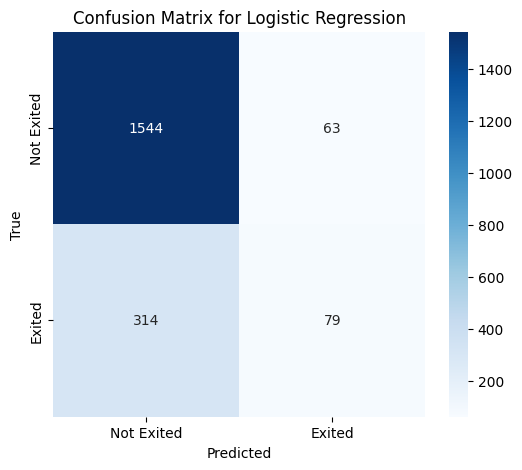

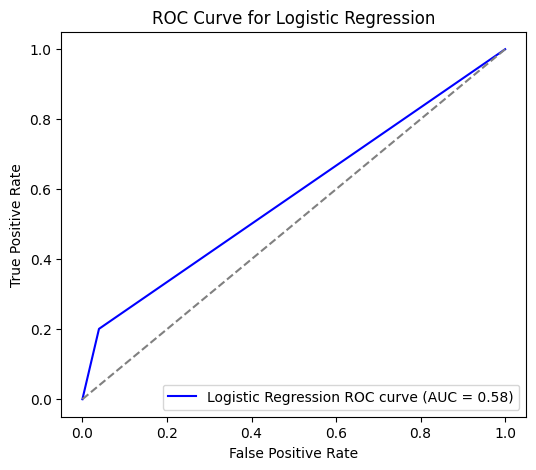

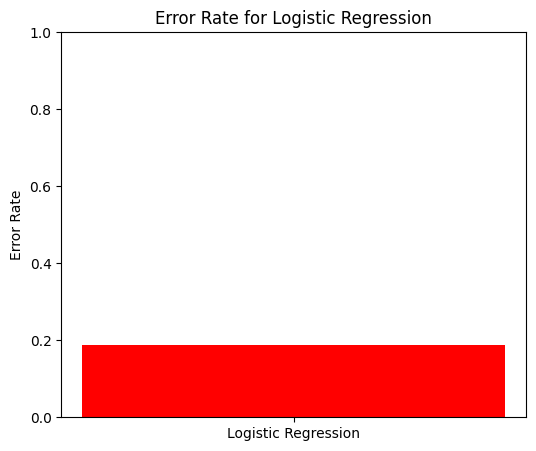

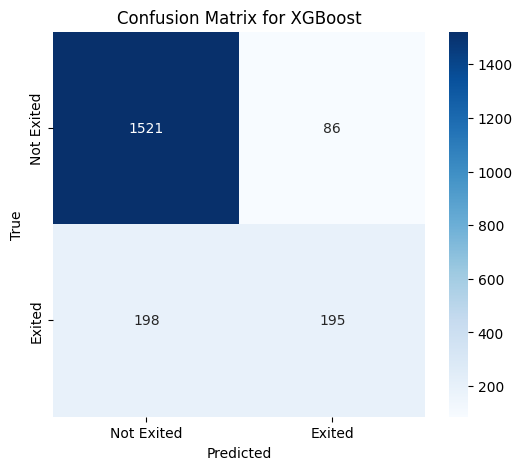

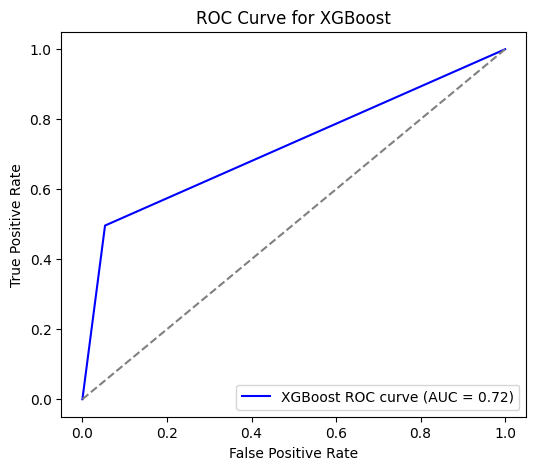

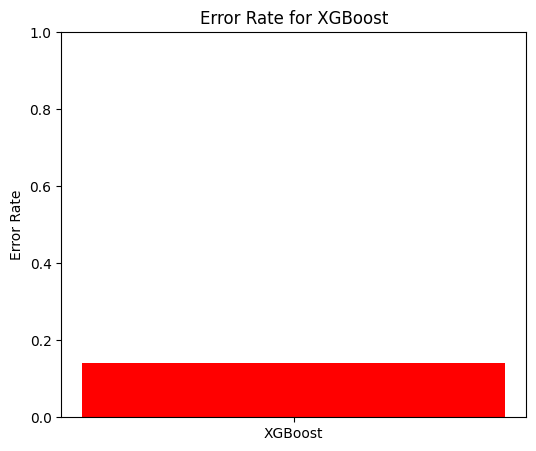

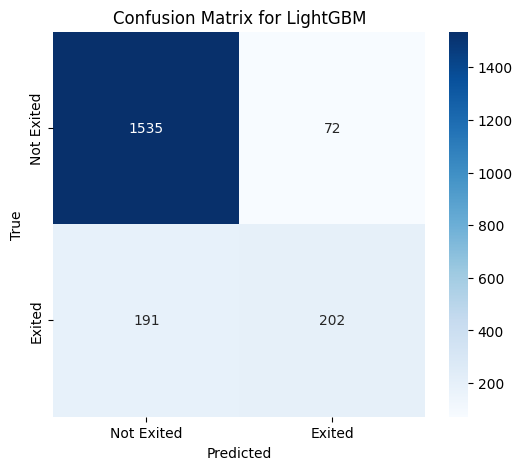

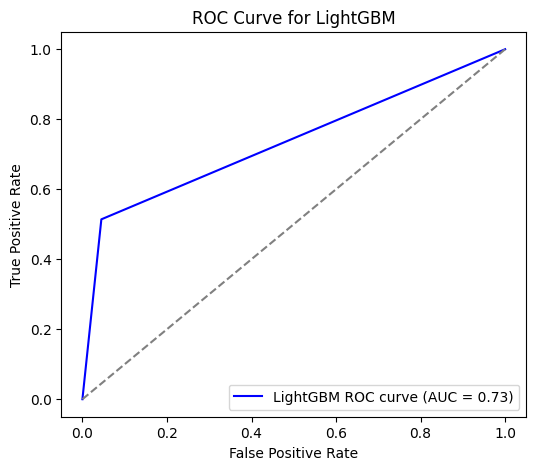

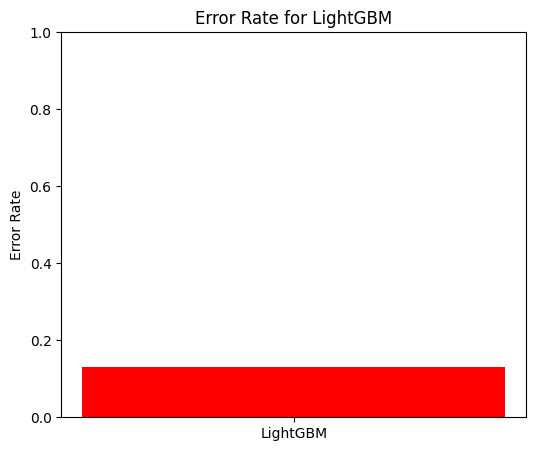

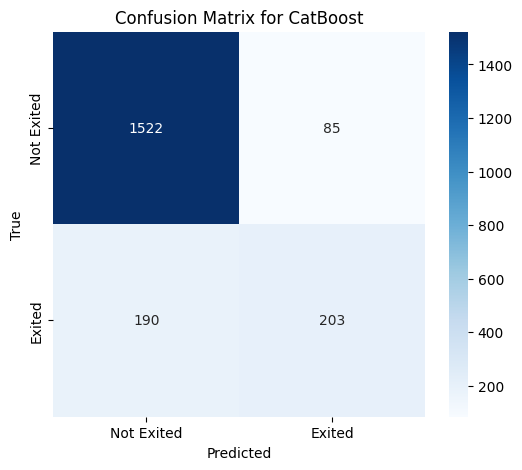

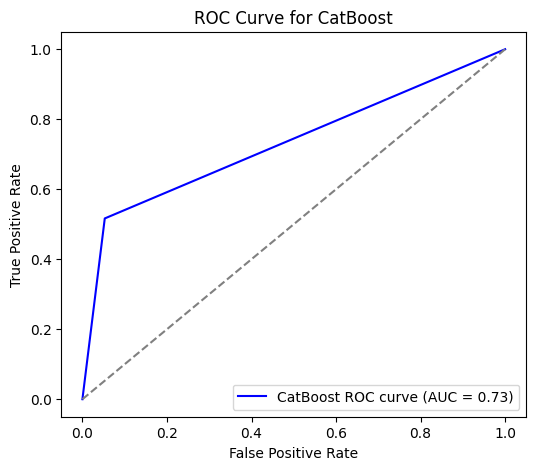

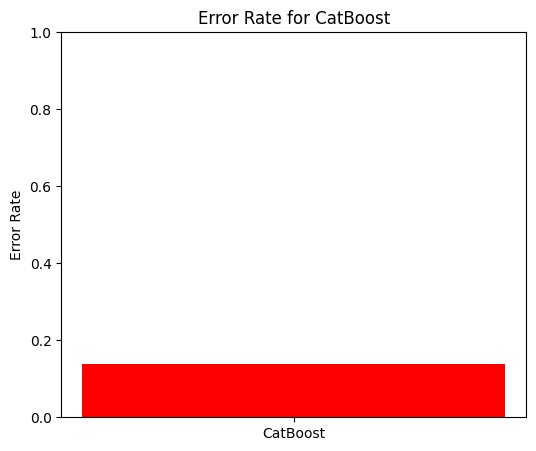

Model Comparison Summary:
                 Model  Accuracy   ROC AUC
0  Logistic Regression    0.8115  0.580907
1              XGBoost    0.8580  0.721334
2             LightGBM    0.8685  0.734595
3             CatBoost    0.8625  0.731823


In [32]:
# Evaluate and visualize for each model
for model_name, predictions in models.items():
    plot_confusion_matrix(y_test, predictions, model_name)
    plot_roc_curve(y_test, predictions, model_name)
    plot_error_plot(y_test, predictions, model_name)

# Plot model comparison summary
plot_model_comparison_summary()